In [70]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [71]:
data = pd.read_csv('data/train.csv')

training_data = data.drop(columns=['SalePrice'])
target = data['SalePrice']

In [72]:
# Encode text data and normalise values
from sklearn.preprocessing import LabelEncoder

df_encoded = training_data.copy()
label_encoders = {}

for col in df_encoded.select_dtypes(include='object'):
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
# Normalise data   
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

df_encoded = df_encoded.fillna(0)
training_data = torch.tensor(df_encoded.values, dtype=torch.float32)
target = torch.tensor(target.values, dtype=torch.float32).view(-1, 1)

In [73]:
model = nn.Sequential(
    nn.Linear(training_data.shape[1], 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
    )

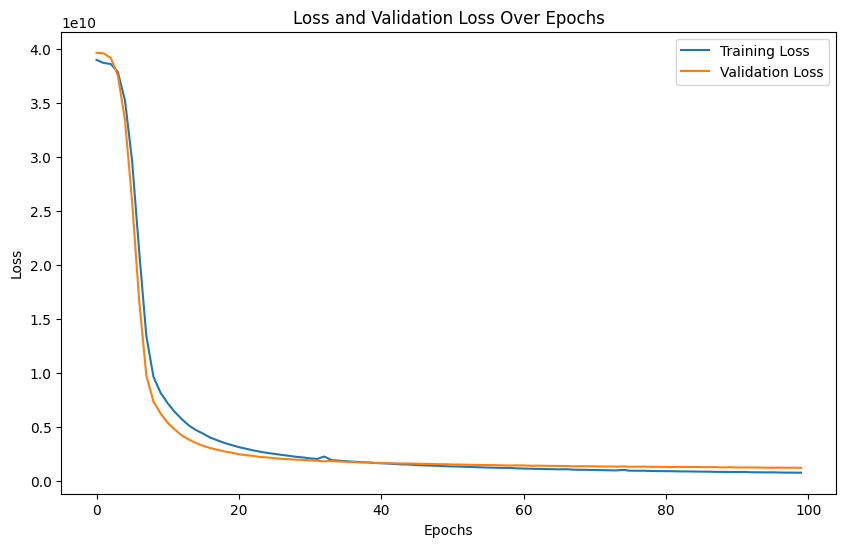

In [74]:
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(training_data, target, test_size=0.2, random_state=42)

# Add batching
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


#Track loss
training_losses = []
validation_losses = []

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    training_losses.append(epoch_loss / len(train_loader))  # Average over batches

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        validation_losses.append(val_loss.item())

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(training_losses, label='Training Loss')
plt.plot(validation_losses, label='Validation Loss')
plt.title('Loss and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()